In [ ]:
from zipfile import ZipFile

zip_path = "/content/Classification_Dataset.zip"
extract_path = "/content/DataSets"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import keras
from keras.utils import to_categorical
from keras.models import Sequential, load_model
from keras.models import Model
from keras.applications.vgg16 import preprocess_input
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping


In [ ]:
curr_path="/content/DataSets/Classification_Dataset"
classes = os.listdir(curr_path)
classes

['Residual_Waste', 'Food_Waste', 'Hazardous_Waste', 'Recyclable_Waste']

In [ ]:
dataset_path = curr_path
img_height, img_width = 224, 224
BATCH_SIZE = 64
SEED=42
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
class_names = train_ds.class_names
print(class_names)
num_classes = len(class_names)

Found 10942 files belonging to 4 classes.
Using 8754 files for training.
Found 10942 files belonging to 4 classes.
Using 2188 files for validation.
['Food_Waste', 'Hazardous_Waste', 'Recyclable_Waste', 'Residual_Waste']


# **ResNet50**

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

image_paths = []
labels = []
class_names = sorted(os.listdir(dataset_path))
class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
num_classes = len(class_names)

# Collect all image paths and their corresponding labels
for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_dir):
        continue

    img_filenames = [os.path.join(class_dir, img) for img in os.listdir(class_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]
    image_paths.extend(img_filenames)
    labels.extend([class_idx] * len(img_filenames))

# Split dataset into training and testing (80% train, 20% test)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)


def load_images(paths, labels):
    X, y = [], []
    for path, label in zip(paths, labels):
        img = cv2.imread(path)
        if img is None:
            continue
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        elif img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
        img = cv2.resize(img, (224, 224))
        X.append(img)
        y.append(label)
    return np.array(X)/255.0, to_categorical(y, num_classes)
X_train, y_train = load_images(train_paths, train_labels)
X_test, y_test = load_images(test_paths, test_labels)



In [ ]:
import random
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything(SEED)


In [ ]:
def get_class_weights(dataset, class_names):
    labels = []
    for _, lbl in dataset.unbatch():
        labels.append(np.argmax(lbl.numpy()))
    class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=labels)
    return dict(enumerate(class_weights))

class_weights = get_class_weights(train_ds, class_names)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="data_augmentation")


In [ ]:

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.AUTOTUNE)


In [ ]:
flat_labels = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(flat_labels), y=flat_labels)
class_weights = dict(enumerate(class_weights))


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Load ResNet50 as the base model
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model initially


# Add classification head
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation="softmax")(x)

# Create model
model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks: Reduce LR, Early Stopping, Checkpoint
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("best_resnet_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[reduce_lr, early_stopping, checkpoint]
)

# Save final model in Keras format
model.save("final_resnet_model.keras")

Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7187 - loss: 0.7913
Epoch 1: val_accuracy improved from -inf to 0.95841, saving model to best_resnet_model.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 68s 365ms/step - accuracy: 0.7196 - loss: 0.7890 - val_accuracy: 0.9584 - val_loss: 0.1245 - learning_rate: 1.0000e-04
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9474 - loss: 0.1622
Epoch 2: val_accuracy improved from 0.95841 to 0.97623, saving model to best_resnet_model.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.9475 - loss: 0.1620 - val_accuracy: 0.9762 - val_loss: 0.0688 - learning_rate: 1.0000e-04
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9759 - loss: 0.0875
Epoch 3: val_accuracy improved from 0.97623 to 0.98126, saving model to best_resnet_model.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 187ms/step - accuracy: 0.9759 - loss: 0.0874 - val_accuracy: 0.9813 - val_loss: 0.0548 - learning_rate: 1.0000e-04
Epoch 4

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
2/2 ━

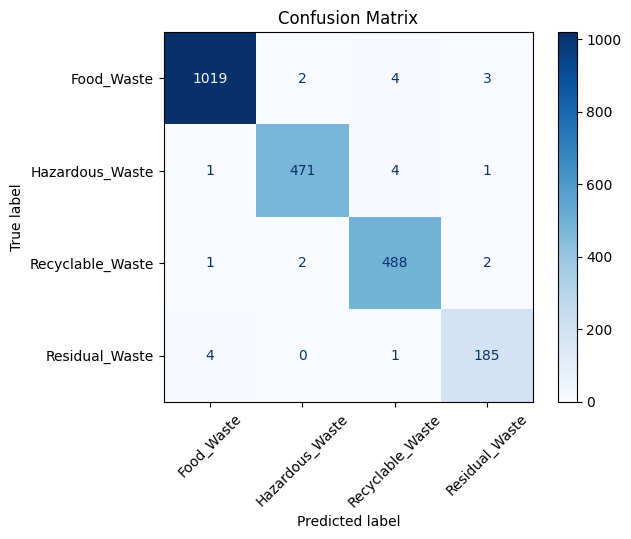

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

                  precision    recall  f1-score   support

      Food_Waste       0.99      0.99      0.99      1028
 Hazardous_Waste       0.99      0.99      0.99       477
Recyclable_Waste       0.98      0.99      0.99       493
  Residual_Waste       0.97      0.97      0.97       190

        accuracy                           0.99      2188
       macro avg       0.98      0.99      0.98      2188
    weighted avg       0.99      0.99      0.99      2188



1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


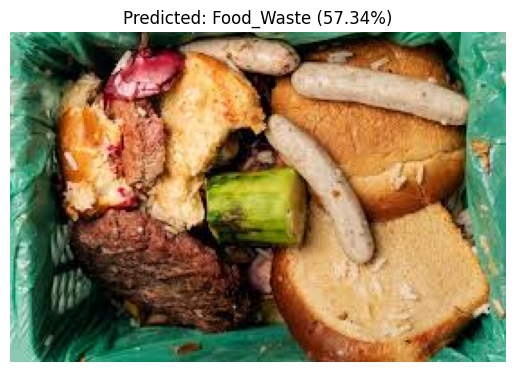

'Food_Waste'

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input
class_names = ['Food_Waste', 'Hazardous_Waste', 'Recyclable_Waste', 'Residual_Waste']

img_width, img_height = 224, 224

def predict_image(img_path, model, class_names):
    img = cv2.imread(img_path)

    if img is None:
        print(f"Error: Could not read image at {img_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = cv2.resize(img, (img_width, img_height))  # Resize to model's input size
    img = np.array(img, dtype=np.float32)  # Convert to float32
    img = preprocess_input(img)  # Normalize for EfficientNet

    img = np.expand_dims(img, axis=0)  # Add batch dimension

    # Predict the waste category
    prediction = model.predict(img)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    # Display the image with prediction
    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {predicted_class} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class
predict_image('/content/food1.jpeg',model,class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


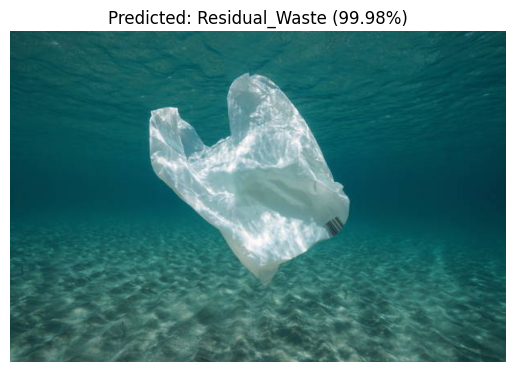

'Residual_Waste'

In [ ]:

predict_image('/content/plastwater.jpg',model,class_names)

# **MobileNetV2**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/Classification_Dataset/New folder (2)/Classification_Dataset.zip"
extract_path = "/content/DataSets"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [ ]:
import os
import tensorflow as tf
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE
DATASET_PATH = "/content/DataSets/Classification_Dataset"

In [ ]:
def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything()

In [ ]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=SEED
)


In [ ]:
def get_image_paths_and_labels(dataset_path):
    image_paths, labels = [], []
    class_names = sorted([
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
    ])

    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(dataset_path, class_name)
        class_files = [
            fname for fname in os.listdir(class_dir)
            if fname.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        for fname in class_files:
            image_paths.append(os.path.join(class_dir, fname))
            labels.append(idx)

        print(f"[INFO] Class '{class_name}': {len(class_files)} images")

    return image_paths, labels, class_names



In [ ]:
image_paths, labels, class_names = get_image_paths_and_labels(DATASET_PATH)
print(f"Total images: {len(image_paths)}")
print(f"Total labels: {len(labels)}")
print(f"Number of classes: {len(class_names)}")

[INFO] Class 'Food_Waste': 5068 images
[INFO] Class 'Hazardous_Waste': 2473 images
[INFO] Class 'Recyclable_Waste': 2446 images
[INFO] Class 'Residual_Waste': 955 images
Total images: 10942
Total labels: 10942
Number of classes: 4


In [ ]:
num_classes = len(set(labels))
def decode_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.one_hot(label, num_classes)

def prepare_dataset(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
], name="augmentation")


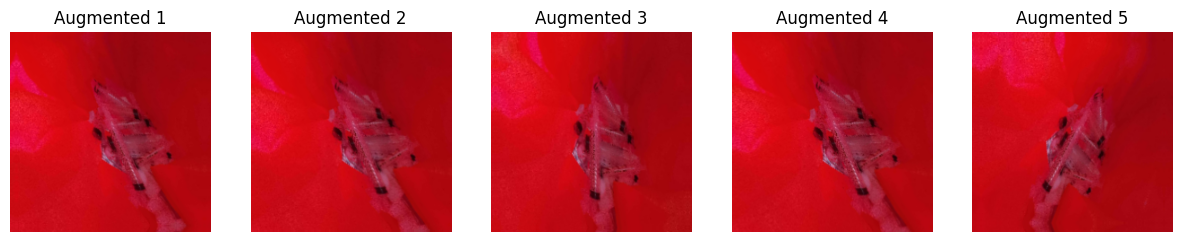

In [ ]:
def load_and_preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32) / 255.0
    return img

image_path = train_paths[0]
image = load_and_preprocess_image(image_path)
image_batch = tf.expand_dims(image, 0)

num_examples = 5
plt.figure(figsize=(15, 5))
for i in range(num_examples):
    augmented_image = data_augmentation(image_batch, training=True)
    augmented_image = tf.squeeze(augmented_image, axis=0)
    plt.subplot(1, num_examples, i + 1)
    plt.imshow(augmented_image.numpy())
    plt.axis('off')
    plt.title(f'Augmented {i+1}')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
def build_fine_tuned_model(base_model_fn, input_shape, num_classes, fine_tune_at=100):
    base_model = base_model_fn(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = True

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = base_model(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

model = build_fine_tuned_model(MobileNetV2, (224, 224, 3), len(class_names), fine_tune_at=100)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=SEED, stratify=labels
)
train_ds = prepare_dataset(train_paths, train_labels, training=True)
val_ds = prepare_dataset(val_paths, val_labels, training=False)


In [ ]:
def train(model, model_name, train_ds, val_ds):
    print(f"[INFO] Training {model_name}...")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    cb = [
        callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{model_name}_best.keras", save_best_only=True),
        callbacks.ReduceLROnPlateau(patience=1)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=cb
    )

    model.save(f"{model_name}_final.keras")
    return history
history = train(model, "MobileNetV2", train_ds, val_ds)


[INFO] Training MobileNetV2...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 108s 320ms/step - accuracy: 0.8358 - loss: 0.4356 - val_accuracy: 0.9680 - val_loss: 0.0871 - learning_rate: 1.0000e-04
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 86s 308ms/step - accuracy: 0.9756 - loss: 0.0764 - val_accuracy: 0.9333 - val_loss: 0.1866 - learning_rate: 1.0000e-04
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 143s 313ms/step - accuracy: 0.9888 - loss: 0.0398 - val_accuracy: 0.9799 - val_loss: 0.0616 - learning_rate: 1.0000e-05
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 140s 307ms/step - accuracy: 0.9892 - loss: 0.0345 - val_accuracy: 0.9863 - val_loss: 0.0440 - learning_rate: 1.0000e-05
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 95s 340ms/step - accuracy: 0.9902 - loss: 0.0307 - val_accuracy: 0.9868 - val_loss: 0.0387 - learning_rate: 1.0000e-05
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 87s 311ms/step - accuracy: 0.9908 - loss: 0.0282 - val_accuracy: 0.9881 - val_loss: 0.0356 - learning_rate: 1.0000e-05
Epoch 7/10
2

In [ ]:
#trial
def train(model, model_name, train_ds, val_ds):
    print(f"[INFO] Training {model_name}...")
    model.compile(optimizer=optimizers.Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    cb = [
        callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{model_name}_best.keras", save_best_only=True),
        callbacks.ReduceLROnPlateau(patience=1)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        callbacks=cb
    )

    model.save(f"{model_name}_final.keras")
    return history
history = train(model, "MobileNetV2", train_ds, val_ds)

[INFO] Training MobileNetV2...
Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 968s 3s/step - accuracy: 0.8366 - loss: 0.4302 - val_accuracy: 0.9388 - val_loss: 0.1877 - learning_rate: 1.0000e-04
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 889s 3s/step - accuracy: 0.9761 - loss: 0.0735 - val_accuracy: 0.9360 - val_loss: 0.2296 - learning_rate: 1.0000e-04
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 860s 3s/step - accuracy: 0.9872 - loss: 0.0435 - val_accuracy: 0.9740 - val_loss: 0.0750 - learning_rate: 1.0000e-05
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 910s 3s/step - accuracy: 0.9904 - loss: 0.0330 - val_accuracy: 0.9826 - val_loss: 0.0478 - learning_rate: 1.0000e-05
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 851s 3s/step - accuracy: 0.9929 - loss: 0.0273 - val_accuracy: 0.9881 - val_loss: 0.0359 - learning_rate: 1.0000e-05


[INFO] Evaluating model...
69/69 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step
                  precision    recall  f1-score   support

      Food_Waste       1.00      1.00      1.00      1014
 Hazardous_Waste       0.97      1.00      0.98       495
Recyclable_Waste       0.99      0.96      0.98       489
  Residual_Waste       0.99      0.98      0.99       191

        accuracy                           0.99      2189
       macro avg       0.99      0.98      0.99      2189
    weighted avg       0.99      0.99      0.99      2189



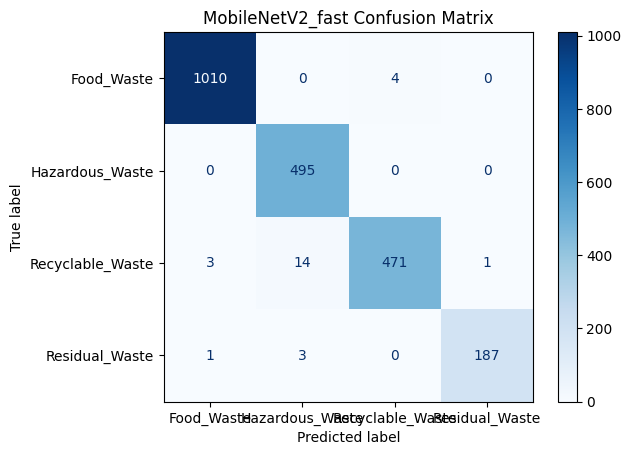

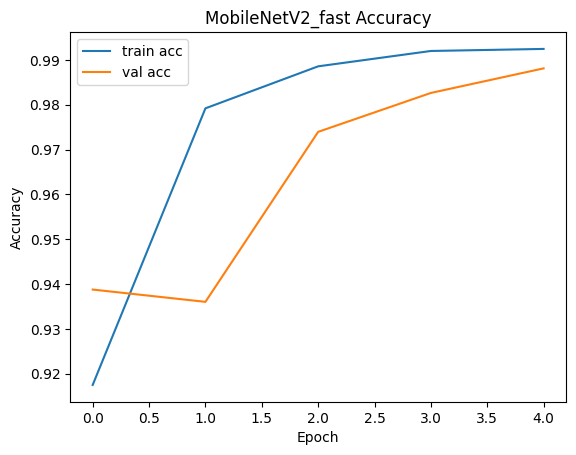

In [ ]:
print("[INFO] Evaluating model...")
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)

y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.title(f"MobileNetV2_fast Confusion Matrix")
plt.show()

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('MobileNetV2_fast Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_width, img_height = 224, 224

def predict_image(img_path, model, class_names):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not read image at {img_path}")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_width, img_height))
    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = np.max(prediction)

    # Plot the result
    plt.imshow(img_rgb)
    plt.title(f"Predicted: {predicted_class} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


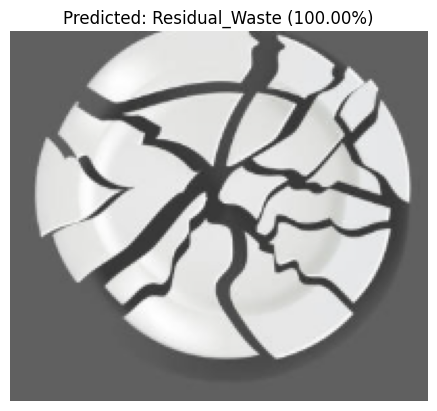

'Residual_Waste'

In [ ]:
# Example usage
predict_image("/content/Screenshot 2025-06-02 142254.png", model, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


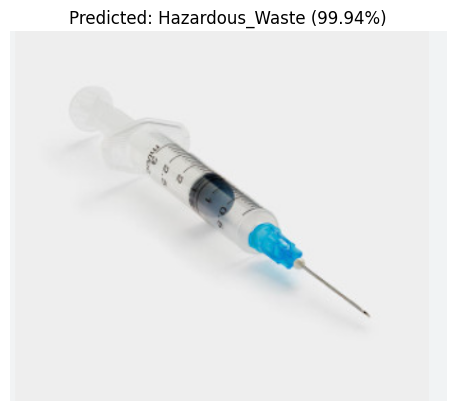

'Hazardous_Waste'

In [ ]:
# Example usage
predict_image("/content/Screenshot 2025-06-02 142830.png", model, class_names)
